# Association vs Causation and Interpretation

In this notebook, we explore a stylized example to illustrate the potential problems with taking associations and model interpretation devices when the goal is to understand causality.

The example is taken from [this article](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/Be%20careful%20when%20interpreting%20predictive%20models%20in%20search%20of%20causal%20insights.html). While artificial, the article and example are motivated from real use cases.

# Python libraries

As usual, we'll start by importing the libraries we'll use.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import sklearn
import xgboost

!pip install shap
import shap

# Functions for Example

The example makes use of artificial data generated to resemble a simple verion of real data one might see in a customer retention setting.

The data are generated in the function `generator`.

We first generate observed predictor variables along with a couple of related unobserved variables.



*   `Sales Calls` (observed): Number of sales calls to the customer
*   `Interactions` (observed): Total number of interactions with the customer
*   `Economy` (observed): State of the customer's regional economy, normalized to the unit interval
*   `Last upgrade` (observed): Time since last upgrade
*   `Product need` (unobserved): How much the customer perceives that they need the product
*   `Discount` (observed): Fractional discount offered to the customer upon renewing
*   `Monthly Usage` (observed): Fraction of days customer used the product over the last period
*   `Ad Spend` (observed): Ad money spent targeting user
*   `Bugs Faced` (unobserved): How many bugs the customer actually experiences
*   `Bugs Reported` (observed): How many bugs the customer reports

We then generate the outcome variable as a binary variable where the probablity the outcome = 1 is a simple logistic function of the generated variables.

The function `user_retention_dataset()` generates the observed variables.

Finally, we will use boosted trees to form our prediction model. We set the parameters in the function `fit_xgboost`.



In [2]:
class FixableDataFrame(pd.DataFrame):
    """Helper class for manipulating generative models."""

    def __init__(self, *args, fixed={}, **kwargs):
        self.__dict__["__fixed_var_dictionary"] = fixed
        super().__init__(*args, **kwargs)

    def __setitem__(self, key, value):
        out = super().__setitem__(key, value)
        if isinstance(key, str) and key in self.__dict__["__fixed_var_dictionary"]:
            out = super().__setitem__(key, self.__dict__["__fixed_var_dictionary"][key])
        return out


# generate the data
def generator(n, fixed={}, seed=0):
    """The generative model for our subscriber retention example."""
    if seed is not None:
        np.random.seed(seed)
    X = FixableDataFrame(fixed=fixed)

    # the number of sales calls made to this customer
    X["Sales calls"] = np.random.uniform(0, 4, size=(n,)).round()

    # the total number of interactions with the customer
    X["Interactions"] = X["Sales calls"] + np.random.poisson(0.2, size=(n,))

    # the health of the regional economy this customer is a part of
    X["Economy"] = np.random.uniform(0, 1, size=(n,))

    # the time since the last product upgrade when this customer came up for renewal
    X["Last upgrade"] = np.random.uniform(0, 20, size=(n,))

    # how much the user perceives that they need the product
    X["Product need"] = X["Sales calls"] * 0.1 + np.random.normal(0, 1, size=(n,))

    # the fractional discount offered to this customer upon renewal
    X["Discount"] = ((1 - scipy.special.expit(X["Product need"])) * 0.5 + 0.5 * np.random.uniform(0, 1, size=(n,))) / 2

    # What percent of the days in the last period was the user actively using the product
    X["Monthly usage"] = scipy.special.expit(X["Product need"] * 0.3 + np.random.normal(0, 1, size=(n,)))

    # how much ad money we spent per user targeted at this user (or a group this user is in)
    X["Ad spend"] = (
        X["Monthly usage"] * np.random.uniform(0.99, 0.9, size=(n,)) + (X["Last upgrade"] < 1) + (X["Last upgrade"] < 2)
    )

    # how many bugs did this user encounter in the since their last renewal
    X["Bugs faced"] = np.array([np.random.poisson(v * 2) for v in X["Monthly usage"]])

    # how many bugs did the user report?
    X["Bugs reported"] = (X["Bugs faced"] * scipy.special.expit(X["Product need"])).round()

    # did the user renew?
    X["Did renew"] = scipy.special.expit(
        7
        * (
            0.18 * X["Product need"]
            + 0.08 * X["Monthly usage"]
            + 0.1 * X["Economy"]
            + 0.05 * X["Discount"]
            + 0.05 * np.random.normal(0, 1, size=(n,))
            + 0.05 * (1 - X["Bugs faced"] / 20)
            + 0.005 * X["Sales calls"]
            + 0.015 * X["Interactions"]
            + 0.1 / (X["Last upgrade"] / 4 + 0.25)
            + X["Ad spend"] * 0.0
            - 0.45
        )
    )

    X["Did renew"] = scipy.stats.bernoulli.rvs(X["Did renew"])

    return X


def user_retention_dataset():
    """The observed data for model training."""
    n = 10000
    X_full = generator(n)
    y = X_full["Did renew"]
    X = X_full.drop(["Did renew", "Product need", "Bugs faced"], axis=1)
    return X, y


def fit_xgboost(X, y):
    """Train an XGBoost model with early stopping."""
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y)
    dtrain = xgboost.DMatrix(X_train, label=y_train)
    dtest = xgboost.DMatrix(X_test, label=y_test)
    model = xgboost.train(
        {"eta": 0.001, "subsample": 0.5, "max_depth": 2, "objective": "reg:logistic"},
        dtrain,
        num_boost_round=200000,
        evals=((dtest, "test"),),
        early_stopping_rounds=20,
        verbose_eval=False,
    )
    return model

# Generate the data and fit the model

In [3]:
X, y = user_retention_dataset()
model = fit_xgboost(X, y)

# Look at variable interpretation measures (SHAP)

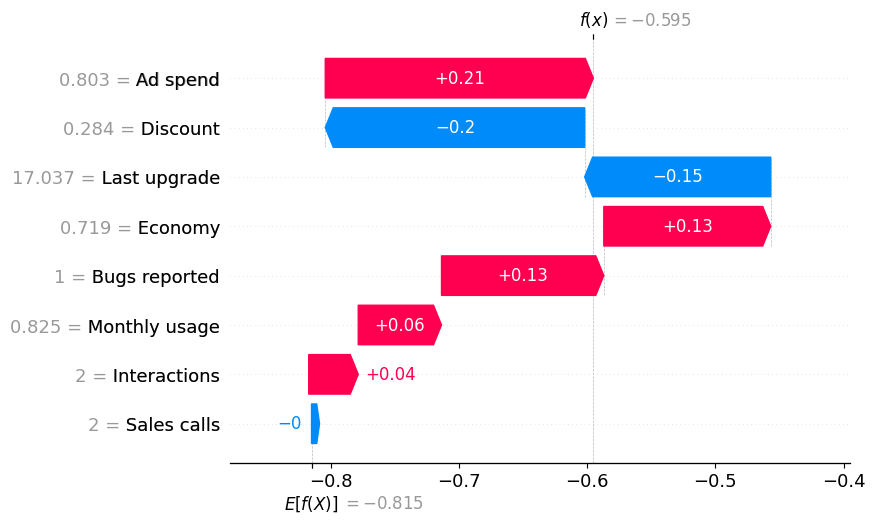

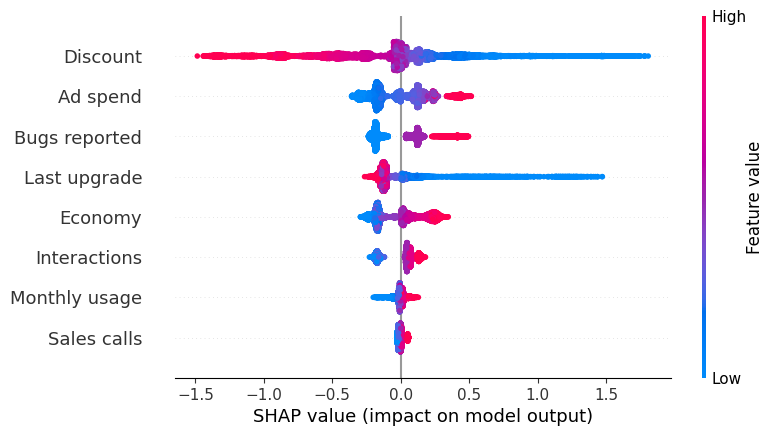

In [4]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

# SHAP for single instance
shap.plots.waterfall(shap_values[0])

# Beeswarm plot - all the SHAP values
shap.plots.beeswarm(shap_values)

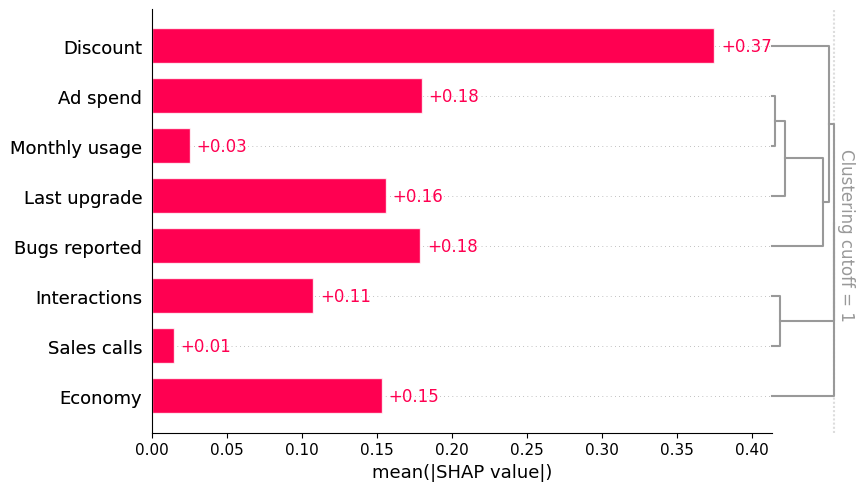

In [5]:
clust = shap.utils.hclust(X, y, linkage="single")
shap.plots.bar(shap_values, clustering=clust, clustering_cutoff=1)

For predicting retention, it looks like `Discount` is the most important variable. There are, however, several other that look relatively important.

The clustering on the right-hand-side of the plot indicates which variables are the most "redundant" in the sense that the model could use either feature and still get same accuracy (with 0 indicating perfectly redundant - there are no perfectly redundant features here).

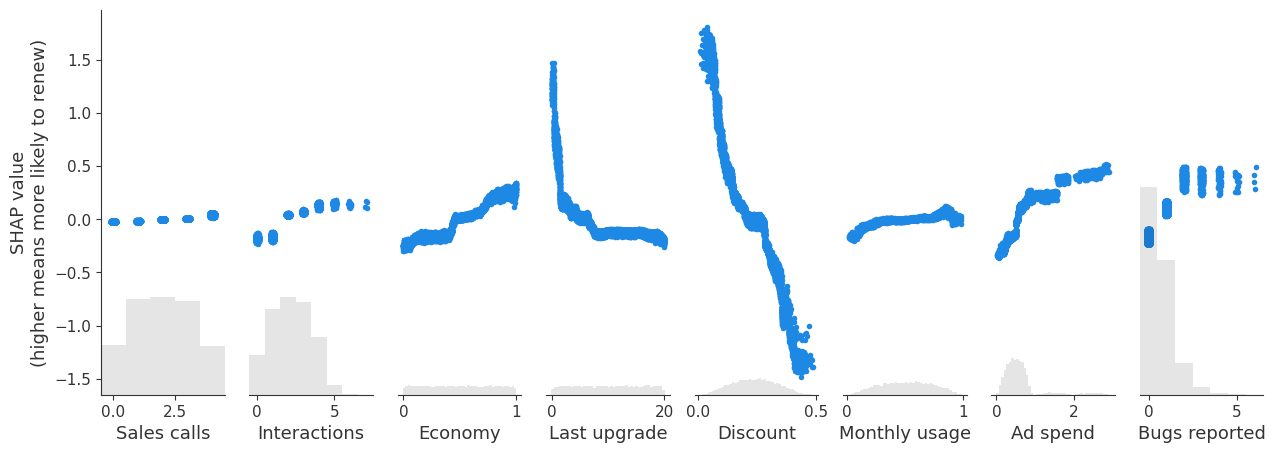

In [6]:
shap.plots.scatter(shap_values,
                   ylabel="SHAP value\n(higher means more likely to renew)")

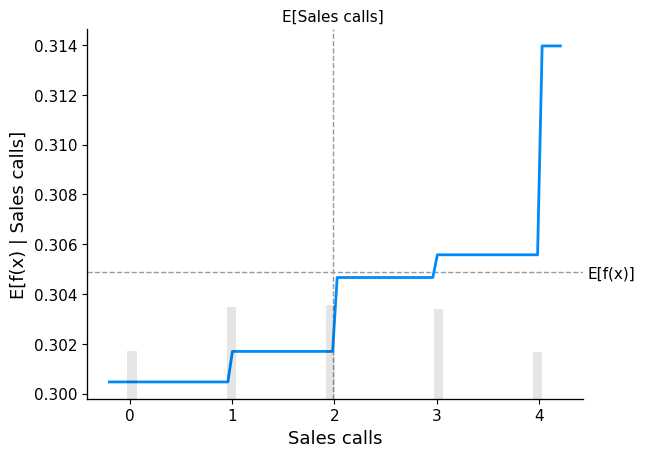

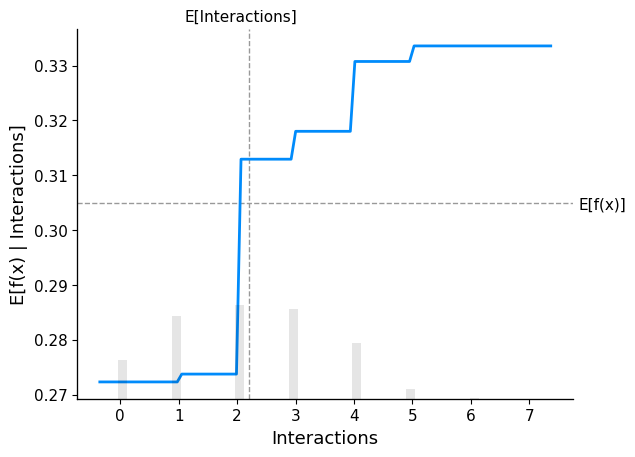

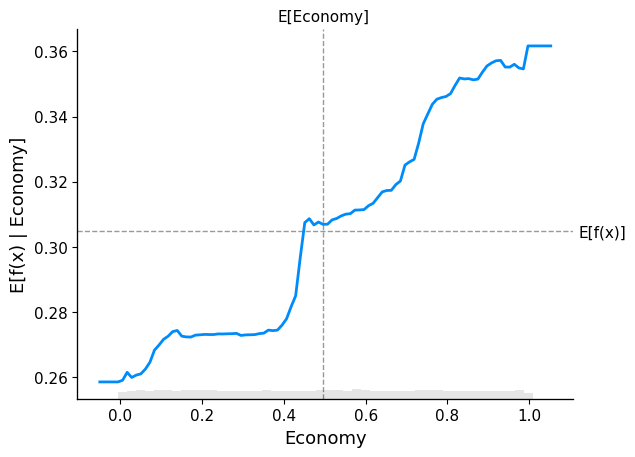

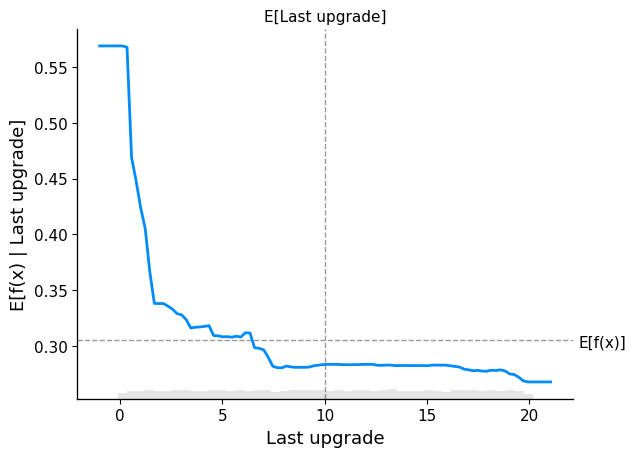

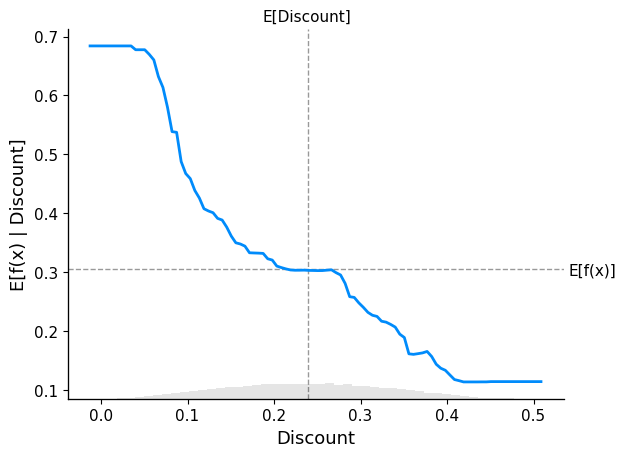

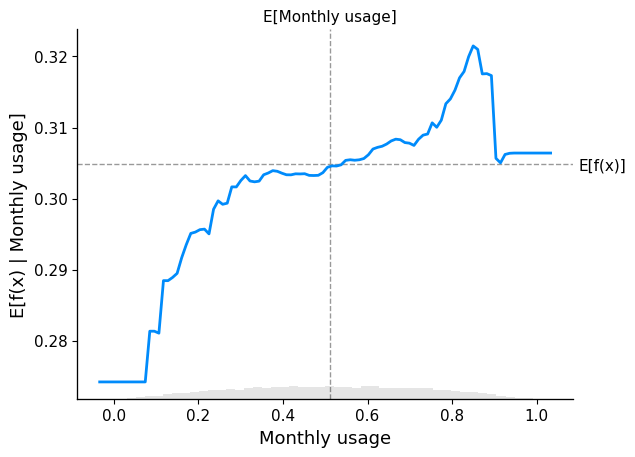

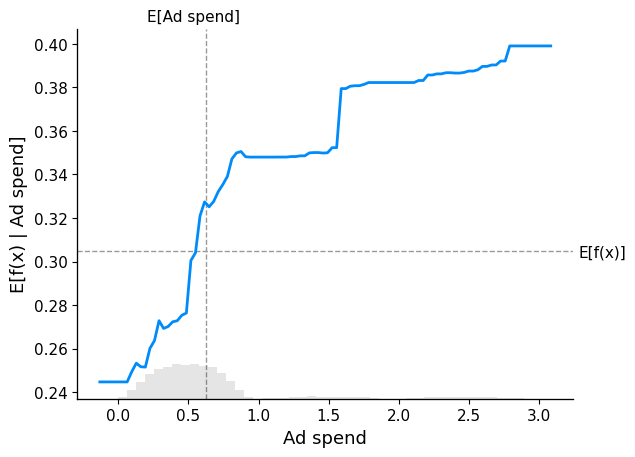

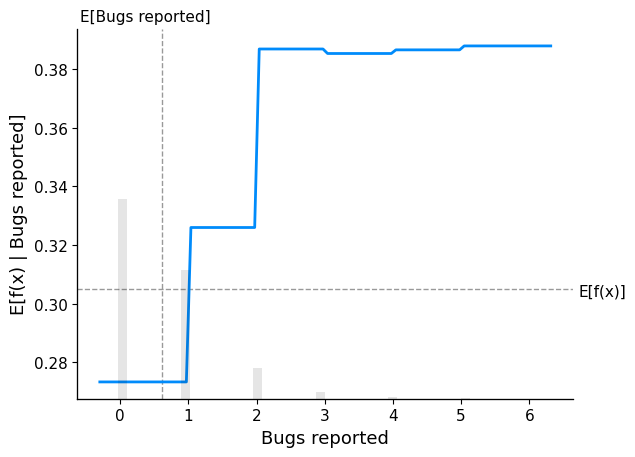

In [7]:
# Traditional partial dependence plot for all variables
for col in X.columns:
    shap.plots.partial_dependence(
        col, lambda x: model.predict(xgboost.DMatrix(x)), X, ice=False, model_expected_value=True, feature_expected_value=True
    )

More interesting, we can look at how predictions change with the value of the input variables.

**It looks like customers who report more bugs are more likely to renew their subscription.**

**It looks like people who get low discounts are less likely to renew their subscription.**

**Is something wrong?**

*   Should we start making our software more buggy to get more long term users?
*   Should we just offer low discounts?
*   How do these questions relate to causality? How to the SHAP plots relate to causality?
*   What should we take away?



# Causal Effects

Because we are using artificial data, we know exactly what the true "causal effects" are. That is, we know exactly how intervening in the system and changing any of our observed variables leaving the rest of the system unchanged will be. We now calculate and plot these effects to illustrate that the observed interpretation measures are misleading if our goal is to learn the causal mechanisms.

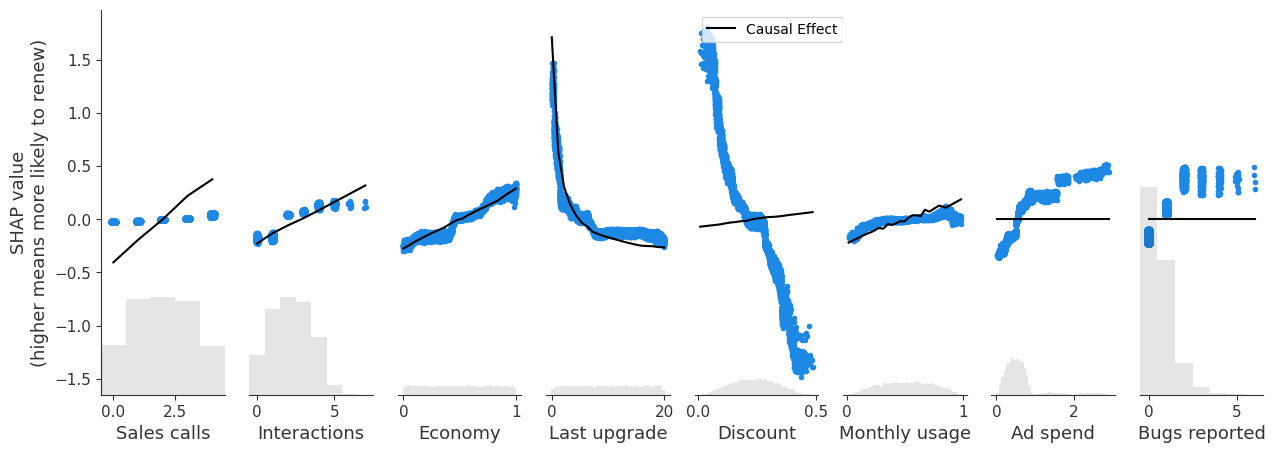

In [8]:
def marginal_effects(generative_model, num_samples=100, columns=None, max_points=20, logit=True, seed=0):
    """Helper function to compute the true marginal causal effects."""
    X = generative_model(num_samples)
    if columns is None:
        columns = X.columns
    ys = [[] for _ in columns]
    xs = [X[c].values for c in columns]
    xs = np.sort(xs, axis=1)
    xs = [xs[i] for i in range(len(xs))]
    for i, c in enumerate(columns):
        xs[i] = np.unique([np.nanpercentile(xs[i], v, method="nearest") for v in np.linspace(0, 100, max_points)])
        for x in xs[i]:
            Xnew = generative_model(num_samples, fixed={c: x}, seed=seed)
            val = Xnew["Did renew"].mean()
            if logit:
                val = scipy.special.logit(val)
            ys[i].append(val)
        ys[i] = np.array(ys[i])
    ys = [ys[i] - ys[i].mean() for i in range(len(ys))]
    return list(zip(xs, ys))


shap.plots.scatter(
    shap_values,
    ylabel="SHAP value\n(higher means more likely to renew)",
    overlay={"Causal Effect": marginal_effects(generator, 10000, X.columns)},
)

**We see that for several of the variables, the causal effects are very different from the predictive effects!!**